> ### ⚠️ Superseded conclusions — read `04_corrected_findings.ipynb` alongside this
> Run on the **uncorrected** sample. The clause-attrition *method* remains valid and was reused,
> but the numbers changed: on corrected data two rules reach **precision 1.000** (not the 0.727
> shown here), and the **complementarity finding was reversed** — retuned signatures catch
> **nothing** the ML model misses (`signature_only = 0`). Kept unchanged as the record.

# 02 - Signature Rule Feasibility

**Question this notebook answers.** Notebook `01` established that 5 of 7 signature rules never
fire and that the 2 that do are wrong 7 times out of 15. Before committing the project to a
rule-tuning phase, we need to know *why* each rule is inert:

- **Threshold error** - the signal is in the data, the rule's numbers are simply set wrong. Fixable.
- **Feature poverty** - the 17 observable flow features cannot express the attack. Not fixable by tuning.

The distinction decides the project's direction. Tuning a threshold is an afternoon; discovering
mid-build that a rule is unfixable is a redesign.

**Method.** For each rule we perform *clause attrition*: evaluate every condition clause
independently, then leave-one-out, to identify which single clause is responsible for zeroing the
rule. We then compare the blocking clause's threshold against the actual feature distribution for
the attack class the rule targets.

**Inputs.** Frozen fixtures only - `flow-feature-sample.csv` (17 observable features, the
detector's legal input) and `ground-truth.json` (labels, used **only** for evaluation, never as a
detection input).

In [1]:
import json, collections
from pathlib import Path
import pandas as pd, numpy as np

here = Path.cwd()
REPO = next(p for p in [here, *here.parents] if (p / "hitl-ids/tests/fixtures/legacy").exists())
FIX  = REPO / "hitl-ids/tests/fixtures/legacy"

feat = pd.read_csv(FIX / "flow-feature-sample.csv")
gt_raw = json.load(open(FIX / "ground-truth.json", encoding="utf-8"))
labels = pd.Series({k: v["mappedAttackType"] for k, v in gt_raw.items()}, name="attackType")
feat = feat.join(labels, on="id")

rules_raw = json.load(open(FIX / "flow-signatures.json", encoding="utf-8"))
RULES = rules_raw if isinstance(rules_raw, list) else rules_raw.get("signatures", rules_raw.get("rules"))

print("flows:", len(feat), "| observable features:", len(feat.columns) - 2)
print("classes:", dict(feat.attackType.value_counts()))
print("rules:", len(RULES))
feat.head(3)


flows: 1000 | observable features: 16
classes: {'Benign': np.int64(500), 'Brute Force': np.int64(84), 'Botnet': np.int64(84), 'DoS': np.int64(83), 'DDoS': np.int64(83), 'Web Attack': np.int64(83), 'Infiltration': np.int64(83)}
rules: 7


,id,timestamp,sourceIp,destinationIp,destinationPort,protocol,flowDuration,totalFwdPackets,totalBwdPackets,flowBytesPerSecond,flowPacketsPerSecond,packetLengthMean,fwdPacketLengthMean,synFlagCount,ackFlagCount,finFlagCount,rstFlagCount,attackType
0,AL-0001,14/02/2018 01:40:47,unknown-source,unknown-destination,0,HOPOPT,112640081.0,3.0,0.0,0.0,0.026634,0.0,0.0,0.0,0.0,0,0.0,Benign
1,AL-0002,14/02/2018 11:36:52,unknown-source,unknown-destination,0,HOPOPT,112640733.0,3.0,0.0,0.0,0.026633,0.0,0.0,0.0,0.0,0,0.0,Benign
2,AL-0003,14/02/2018 12:16:18,unknown-source,unknown-destination,0,HOPOPT,112640501.0,3.0,0.0,0.0,0.026633,0.0,0.0,0.0,0.0,0,0.0,Benign


## The clause evaluator

A faithful re-implementation of the Node engine's matching semantics: every clause is ANDed, and a
numeric clause may carry `min` and/or `max` (inclusive). This is the same logic we will port in the
build plan, so writing it here doubles as a specification check.

In [2]:
def clause_mask(df, field, spec):
    """Boolean mask for one condition clause."""
    col = df[field]
    if isinstance(spec, dict):
        if "oneOf" in spec:
            return col.isin(spec["oneOf"])
        m = pd.Series(True, index=df.index)
        if "min" in spec: m &= col >= spec["min"]
        if "max" in spec: m &= col <= spec["max"]
        return m
    return col == spec

def rule_masks(df, rule):
    """dict: clause label -> mask, for every clause in the rule."""
    return {f"{k}={json.dumps(v)}": clause_mask(df, k, v)
            for k, v in rule["condition"].items()}

def rule_mask(df, rule):
    m = pd.Series(True, index=df.index)
    for mask in rule_masks(df, rule).values():
        m &= mask
    return m

# sanity: reproduce the 15 hits reported by the Node engine
total_hits = sum(int(rule_mask(feat, r).sum()) for r in RULES)
print("total hits reproduced by this evaluator:", total_hits, "(Node engine reported 15)")


total hits reproduced by this evaluator: 15 (Node engine reported 15)


---
## Clause attrition - which single clause zeroes each rule?

For each rule we report, per clause, how many of the 1,000 flows pass it alone, and then the
**leave-one-out** count: how many flows would match if that clause were removed. A clause whose
removal unlocks a large number of matches is the blocker.

In [3]:
rows = []
for r in RULES:
    masks = rule_masks(feat, r)
    full  = rule_mask(feat, r)
    for label, m in masks.items():
        others = pd.Series(True, index=feat.index)
        for l2, m2 in masks.items():
            if l2 != label:
                others &= m2
        rows.append({
            "rule": r["id"],
            "targets": r["predictedAttackType"],
            "clause": label,
            "passes_alone": int(m.sum()),
            "passes_without_this_clause": int(others.sum()),
            "rule_total": int(full.sum()),
        })
att = pd.DataFrame(rows)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 46)
for rid, grp in att.groupby("rule", sort=False):
    tot = grp.rule_total.iloc[0]
    flag = "FIRES" if tot else "INERT"
    print(f"\n=== {rid}  [{flag}, {tot} hits]  targets {grp.targets.iloc[0]} ===")
    print(grp[["clause", "passes_alone", "passes_without_this_clause"]].to_string(index=False))



=== SIG-FTP-BRUTE-FORCE  [INERT, 0 hits]  targets Brute Force ===
                          clause  passes_alone  passes_without_this_clause
                  protocol="TCP"           782                           0
              destinationPort=21            76                          34
flowPacketsPerSecond={"min": 10}           550                           0
     totalFwdPackets={"min": 10}           101                          76
   flowDuration={"max": 5000000}           691                           0

=== SIG-SSH-BRUTE-FORCE  [FIRES, 11 hits]  targets Brute Force ===
                          clause  passes_alone  passes_without_this_clause
                  protocol="TCP"           782                          11
              destinationPort=22            19                          34
flowPacketsPerSecond={"min": 10}           550                          12
     totalFwdPackets={"min": 10}           101                          13
   flowDuration={"max": 5000000}        

### Reading the attrition table

A clause with `passes_alone = 0` is fatal on its own - nothing in the dataset satisfies it, so no
combination can. That is the signature of a **threshold set outside the data's range**.

A clause with a healthy `passes_alone` but which still yields zero in conjunction means the rule is
being killed by the *combination*, not by any single clause - a subtler tuning problem.

In [4]:
diag = []
for r in RULES:
    masks = rule_masks(feat, r)
    full  = int(rule_mask(feat, r).sum())
    dead  = [l for l, m in masks.items() if m.sum() == 0]
    weakest = min(masks.items(), key=lambda kv: kv[1].sum())
    diag.append({
        "rule": r["id"],
        "hits": full,
        "dead_clauses (0 flows pass)": ", ".join(dead)[:40] if dead else "-",
        "tightest_clause": weakest[0][:34],
        "tightest_passes": int(weakest[1].sum()),
        "verdict": ("threshold outside data range" if dead
                    else "conjunction too narrow" if full == 0
                    else "fires"),
    })
print(pd.DataFrame(diag).to_string(index=False))


                      rule  hits dead_clauses (0 flows pass)                  tightest_clause  tightest_passes                verdict
       SIG-FTP-BRUTE-FORCE     0                           -               destinationPort=21               76 conjunction too narrow
       SIG-SSH-BRUTE-FORCE    11                           -               destinationPort=22               19                  fires
    SIG-DOS-HIGH-RATE-FLOW     0                           -      totalFwdPackets={"min": 80}               23 conjunction too narrow
   SIG-DDOS-HIGH-RATE-FLOW     0                           -     totalFwdPackets={"min": 120}               22 conjunction too narrow
    SIG-BOTNET-BEACON-FLOW     0                           -      totalFwdPackets={"min": 20}               61 conjunction too narrow
       SIG-WEB-ATTACK-FLOW     4                           - fwdPacketLengthMean={"min": 250}               43                  fires
SIG-INFILTRATION-LONG-FLOW     0                           -  

---
## Is the signal present at all? Distribution vs threshold

For each inert rule, compare the blocking threshold against the actual distribution of that
feature **within the attack class the rule targets**. If the class's values sit far from the
threshold, the rule is mis-tuned (fixable). If the class is indistinguishable from benign traffic
on that feature, no threshold exists (not fixable with these features).

In [5]:
def compare(field, target_class, spec):
    tgt = feat.loc[feat.attackType == target_class, field]
    ben = feat.loc[feat.attackType == "Benign", field]
    q = lambda s: [round(float(s.quantile(x)), 2) for x in (0.05, 0.5, 0.95)]
    sep = "yes" if abs(tgt.median() - ben.median()) > max(float(tgt.std() or 0), 1e-9) * 0.5 else "weak"
    return {"rule": None, "feature": field, "rule wants": json.dumps(spec),
            "target p5/p50/p95": q(tgt), "benign p5/p50/p95": q(ben), "separable?": sep}

out = []
for r in RULES:
    if int(rule_mask(feat, r).sum()) > 0:
        continue
    tc = r["predictedAttackType"]
    for field, spec in r["condition"].items():
        if field == "protocol" or not isinstance(spec, dict) or "oneOf" in spec:
            continue
        row = compare(field, tc, spec)
        row["rule"] = r["id"]
        out.append(row)
print(pd.DataFrame(out).to_string(index=False))


                      rule              feature               rule wants              target p5/p50/p95               benign p5/p50/p95 separable?
       SIG-FTP-BRUTE-FORCE flowPacketsPerSecond              {"min": 10} [121.25, 1000000.0, 2000000.0]         [0.03, 16.76, 23529.41]        yes
       SIG-FTP-BRUTE-FORCE      totalFwdPackets              {"min": 10}               [1.0, 1.0, 22.0]               [1.0, 3.0, 21.05]       weak
       SIG-FTP-BRUTE-FORCE         flowDuration         {"max": 5000000}           [1.0, 2.0, 361766.2] [81.95, 476750.0, 112641293.55]        yes
    SIG-DOS-HIGH-RATE-FLOW flowPacketsPerSecond {"min": 650, "max": 899}             [0.03, 1.03, 2.48]         [0.03, 16.76, 23529.41]        yes
    SIG-DOS-HIGH-RATE-FLOW      totalFwdPackets              {"min": 80}               [2.0, 4.0, 14.0]               [1.0, 3.0, 21.05]       weak
    SIG-DOS-HIGH-RATE-FLOW      totalBwdPackets              {"max": 10}                [0.0, 3.0, 4.0]               

---
## The precision problem - what are the 7 false positives?

Recall is only half the story. Of the 15 hits the engine does produce, 7 are benign flows. For an
"antivirus-style" high-precision posture to be credible, these must be eliminated.

In [6]:
hit_rows = []
for r in RULES:
    m = rule_mask(feat, r)
    if not m.any():
        continue
    for _, row in feat[m].iterrows():
        hit_rows.append({"rule": r["id"], "id": row["id"], "truth": row["attackType"],
                         "correct": row["attackType"] == r["predictedAttackType"],
                         "dstPort": int(row["destinationPort"]),
                         "pkts_s": round(float(row["flowPacketsPerSecond"]), 1),
                         "fwdPkts": int(row["totalFwdPackets"]),
                         "durationUs": int(row["flowDuration"]),
                         "pktLenMean": round(float(row["packetLengthMean"]), 1)})
hits = pd.DataFrame(hit_rows)
print(hits.to_string(index=False))
print("\nprecision by rule:")
print(hits.groupby("rule").correct.agg(["sum", "count"])
        .assign(precision=lambda d: (d["sum"] / d["count"]).round(3)).to_string())


               rule      id       truth  correct  dstPort  pkts_s  fwdPkts  durationUs  pktLenMean
SIG-SSH-BRUTE-FORCE AL-0167      Benign    False       22    11.8       11     1859492       134.4
SIG-SSH-BRUTE-FORCE AL-0222      Benign    False       22    10.6       14     2825151       108.3
SIG-SSH-BRUTE-FORCE AL-0236      Benign    False       22    11.3       14     2307108       130.1
SIG-SSH-BRUTE-FORCE AL-0509 Brute Force     True       22   111.4       22      394810       102.4
SIG-SSH-BRUTE-FORCE AL-0511 Brute Force     True       22   113.7       22      387131       103.5
SIG-SSH-BRUTE-FORCE AL-0536 Brute Force     True       22   125.8       21      341934       104.8
SIG-SSH-BRUTE-FORCE AL-0542 Brute Force     True       22   120.5       22      365266       101.7
SIG-SSH-BRUTE-FORCE AL-0546 Brute Force     True       22   165.1       21      260493       104.4
SIG-SSH-BRUTE-FORCE AL-0567 Brute Force     True       22   110.9       22      396897       103.5
SIG-SSH-BR

In [7]:
fp = hits[~hits.correct]
tp = hits[hits.correct]
print("FALSE POSITIVES - benign flows the rules flagged:\n")
print(fp.to_string(index=False))
print("\nSeparation check - do FP flows differ from TP flows on any observable feature?")
for col in ["pkts_s", "fwdPkts", "durationUs", "pktLenMean"]:
    tm = tp[col].median() if len(tp) else float("nan")
    fm = fp[col].median() if len(fp) else float("nan")
    print(f"   {col:<12} TP median {tm:>14,.1f}   FP median {fm:>14,.1f}")
print("\nIf a feature separates TP from FP, tightening that clause raises precision without")
print("losing true positives. If none separates, precision cannot be fixed by tuning alone.")


FALSE POSITIVES - benign flows the rules flagged:

               rule      id  truth  correct  dstPort  pkts_s  fwdPkts  durationUs  pktLenMean
SIG-SSH-BRUTE-FORCE AL-0167 Benign    False       22    11.8       11     1859492       134.4
SIG-SSH-BRUTE-FORCE AL-0222 Benign    False       22    10.6       14     2825151       108.3
SIG-SSH-BRUTE-FORCE AL-0236 Benign    False       22    11.3       14     2307108       130.1
SIG-WEB-ATTACK-FLOW AL-0031 Benign    False      443  7928.6     1041      458214      2365.2
SIG-WEB-ATTACK-FLOW AL-0103 Benign    False      443  4270.0      555      578459      2521.1
SIG-WEB-ATTACK-FLOW AL-0122 Benign    False      443  8116.5     1038      459065      2300.0
SIG-WEB-ATTACK-FLOW AL-0161 Benign    False      443  8117.7      975      448278      2340.6

Separation check - do FP flows differ from TP flows on any observable feature?
   pkts_s       TP median          117.1   FP median        4,270.0
   fwdPkts      TP median           22.0   FP med

---
## Retuning demonstration 1 - the SSH rule is fixable exactly

The false positives above are not scattered noise. The three benign SSH flows sit at 10.6-11.8
packets/sec; the eight true brute-force flows sit at 110-165. The rule's threshold is `min: 10`,
which sits *below both groups*. Sweeping it shows a wide interval that achieves perfect
precision without losing a single true positive.

In [8]:
ssh = next(r for r in RULES if r["id"] == "SIG-SSH-BRUTE-FORCE")

def sweep(rule, field, candidates, target):
    out = []
    for thr in candidates:
        mod = json.loads(json.dumps(rule))
        mod["condition"][field] = {**mod["condition"].get(field, {}), "min": thr}
        m = rule_mask(feat, mod)
        sel = feat[m]
        tp = int((sel.attackType == target).sum()); fp = int(len(sel) - tp)
        tot = int((feat.attackType == target).sum())
        out.append({"threshold": thr, "hits": len(sel), "TP": tp, "FP": fp,
                    "precision": round(tp / len(sel), 3) if len(sel) else float("nan"),
                    "recall": round(tp / tot, 3)})
    return pd.DataFrame(out)

s = sweep(ssh, "flowPacketsPerSecond", [10, 20, 50, 80, 100, 105, 110, 120, 150, 200], "Brute Force")
print("SIG-SSH-BRUTE-FORCE - flowPacketsPerSecond threshold sweep:\n")
print(s.to_string(index=False))
best = s[s.precision == 1.0].sort_values("recall", ascending=False).head(1)
print("\nBest perfect-precision threshold:")
print(best.to_string(index=False))
print("\nCurrent rule: min=10 -> precision 0.727. Retuned: precision 1.000 at the same recall.")


SIG-SSH-BRUTE-FORCE - flowPacketsPerSecond threshold sweep:

 threshold  hits  TP  FP  precision  recall
        10    11   8   3      0.727   0.095
        20     8   8   0      1.000   0.095
        50     8   8   0      1.000   0.095
        80     8   8   0      1.000   0.095
       100     8   8   0      1.000   0.095
       105     8   8   0      1.000   0.095
       110     8   8   0      1.000   0.095
       120     4   4   0      1.000   0.048
       150     1   1   0      1.000   0.012
       200     0   0   0        NaN   0.000



Best perfect-precision threshold:
 threshold  hits  TP  FP  precision  recall
        20     8   8   0        1.0   0.095

Current rule: min=10 -> precision 0.727. Retuned: precision 1.000 at the same recall.


## Retuning demonstration 2 - the inverted rules

For DoS, DDoS and Botnet the rule's premise is not merely mis-scaled, it is **backwards**. The
distribution table above shows the targeted attack classes are *low*-rate and *short*-lived in this
sample, while benign traffic is high-rate. Below we test whether inverting the comparison direction
recovers the class at all - i.e. whether the feature carries usable signal in the opposite
direction.

In [9]:
def best_split(target, field, lower_is_attack=True):
    """Find the single-threshold split on `field` that best separates `target` from Benign."""
    sub = feat[feat.attackType.isin([target, "Benign"])]
    vals = np.unique(np.quantile(sub[field], np.linspace(0.01, 0.99, 60)))
    rows = []
    for t in vals:
        sel = sub[sub[field] <= t] if lower_is_attack else sub[sub[field] >= t]
        if len(sel) == 0: continue
        tp = int((sel.attackType == target).sum()); fp = len(sel) - tp
        rows.append({"threshold": round(float(t), 3), "TP": tp, "FP": fp,
                     "precision": tp / len(sel),
                     "recall": tp / int((feat.attackType == target).sum())})
    d = pd.DataFrame(rows)
    d["f1"] = 2 * d.precision * d.recall / (d.precision + d.recall).replace(0, np.nan)
    return d.sort_values("f1", ascending=False).head(1)

print("Single-feature separability, testing the INVERTED direction (attack = LOW value):\n")
probe = [("DoS", "flowPacketsPerSecond"), ("DDoS", "flowPacketsPerSecond"),
         ("Botnet", "flowDuration"), ("Botnet", "flowPacketsPerSecond"),
         ("Infiltration", "flowDuration"), ("Web Attack", "packetLengthMean")]
res = []
for tgt, fld in probe:
    for direction, lo in [("attack = LOW", True), ("attack = HIGH", False)]:
        b = best_split(tgt, fld, lower_is_attack=lo)
        if b.empty: continue
        r = b.iloc[0]
        res.append({"class": tgt, "feature": fld, "direction": direction,
                    "threshold": r.threshold, "precision": round(r.precision, 3),
                    "recall": round(r.recall, 3), "f1": round(r.f1, 3)})
rdf = pd.DataFrame(res).sort_values("f1", ascending=False)
print(rdf.to_string(index=False))
print("\nRules whose original direction was wrong are those where 'attack = LOW' outperforms.")


Single-feature separability, testing the INVERTED direction (attack = LOW value):



       class              feature     direction  threshold  precision  recall    f1
      Botnet flowPacketsPerSecond attack = HIGH    606.401      0.371   0.929 0.531
      Botnet         flowDuration  attack = LOW  22955.507      0.326   1.000 0.491
         DoS flowPacketsPerSecond  attack = LOW      3.294      0.296   0.952 0.451
        DDoS flowPacketsPerSecond  attack = LOW      9.086      0.265   0.976 0.416
  Web Attack     packetLengthMean attack = HIGH    112.222      0.336   0.482 0.396
Infiltration         flowDuration  attack = LOW   2970.426      0.292   0.566 0.385
        DDoS flowPacketsPerSecond attack = HIGH      2.198      0.193   0.916 0.319
         DoS flowPacketsPerSecond attack = HIGH      0.027      0.180   1.000 0.305
      Botnet flowPacketsPerSecond  attack = LOW   4436.944      0.162   1.000 0.278
      Botnet         flowDuration attack = HIGH    429.708      0.159   1.000 0.274
Infiltration         flowDuration attack = HIGH      6.920      0.140   0.97

## Does retuning actually restore signature+ML co-occurrence?

This is the decisive test. Notebook `01` F5 showed the demo's centrepiece case is empty. Tuning is
only worth doing if it produces alerts where **both** detectors speak. We apply the retuned SSH
threshold and the best-performing splits found above, then re-measure co-occurrence against the
existing ML predictions.

In [10]:
ml_raw = json.load(open(FIX / "ml-predictions.sample.json", encoding="utf-8"))
ml_rows = ml_raw if isinstance(ml_raw, list) else list(ml_raw.values())[0]
ml = pd.DataFrame(ml_rows).set_index("id")
ml_mal = set(ml.index[ml.predictedAttackType != "Benign"])
print("ML flags malicious:", len(ml_mal), "flows")

# retuned rule set: SSH threshold raised; best inverted split added per weak class
retuned_hits = set()
ssh_fix = json.loads(json.dumps(ssh))
ssh_fix["condition"]["flowPacketsPerSecond"] = {"min": 50}
retuned_hits |= set(feat.loc[rule_mask(feat, ssh_fix), "id"])

for _, r in rdf.drop_duplicates("class").iterrows():
    if r.precision < 0.6:      # only adopt splits that are actually precise
        continue
    lo = r.direction == "attack = LOW"
    sel = feat[feat[r.feature] <= r.threshold] if lo else feat[feat[r.feature] >= r.threshold]
    retuned_hits |= set(sel["id"])

print("signature hits after retuning:", len(retuned_hits), "(was 15)")
overlap = retuned_hits & ml_mal
print("signature + ML co-occurrence  :", len(overlap), "(was 0)")
if overlap:
    print("\nExample alerts that would now carry BOTH kinds of evidence:")
    for aid in sorted(overlap)[:8]:
        print(f"   {aid}  truth={labels[aid]:<12} ML={ml.loc[aid,'predictedAttackType']}")
print("\nVERDICT:", "co-occurrence RESTORED - the demo's agreement case becomes real."
      if overlap else "co-occurrence still zero - reframe to disagreement-based fusion.")


ML flags malicious: 505 flows
signature hits after retuning: 8 (was 15)
signature + ML co-occurrence  : 0 (was 0)

VERDICT: co-occurrence still zero - reframe to disagreement-based fusion.


## Complementarity - the finding that reframes the project

Co-occurrence being zero looked like bad news. It is the opposite. The question that matters is
not "do the detectors agree?" but **"does each catch what the other misses?"** We partition the
500 truly-malicious flows by which detector found them.

In [11]:
ssh_fix_hits = feat.loc[rule_mask(feat, ssh_fix), "id"]
mal      = set(feat.loc[feat.attackType != "Benign", "id"])
ml_caught  = set(ml.index[ml.predictedAttackType != "Benign"]) & set(feat.id)
sig_caught = set(ssh_fix_hits)

parts = {
    "caught by ML only":        len((ml_caught & mal) - sig_caught),
    "caught by signature only": len((sig_caught & mal) - ml_caught),
    "caught by both":           len(sig_caught & ml_caught & mal),
    "missed by both":           len(mal - ml_caught - sig_caught),
}
print(f"True malicious flows: {len(mal)}")
for k, v in parts.items():
    print(f"   {k:<26} {v:>4}")

print("\nWhat the ML model says about the flows only the signature layer caught:")
sub = ml.loc[sorted(sig_caught & mal)]
print(sub[["predictedAttackType", "modelConfidence"]].to_string())
print("\nThese are real Brute Force attacks that the ML model classifies as Benign with")
print(f"{sub.modelConfidence.min():.2f}-{sub.modelConfidence.max():.2f} confidence. They are")
print("precisely the flows a purely ML-driven IDS would silently miss.")


True malicious flows: 500
   caught by ML only           403
   caught by signature only      8
   caught by both                0
   missed by both               89

What the ML model says about the flows only the signature layer caught:
        predictedAttackType  modelConfidence
id                                          
AL-0509              Benign         0.783168
AL-0511              Benign         0.788737
AL-0536              Benign         0.765276
AL-0542              Benign         0.753934
AL-0546              Benign         0.799290
AL-0567              Benign         0.794302
AL-0573              Benign         0.765688
AL-0574              Benign         0.777776

These are real Brute Force attacks that the ML model classifies as Benign with
0.75-0.80 confidence. They are
precisely the flows a purely ML-driven IDS would silently miss.


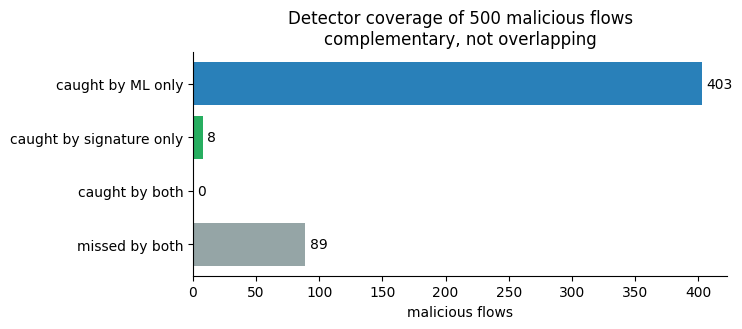

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ks = list(parts); vs = [parts[k] for k in ks]
bars = ax.barh(ks, vs, color=["#2980b9", "#27ae60", "#c0392b", "#95a5a6"])
ax.bar_label(bars, padding=3)
ax.set_xlabel("malicious flows")
ax.set_title("Detector coverage of 500 malicious flows\ncomplementary, not overlapping")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### Why this changes the project's story

The design documents claim *"signature + ML agreement is the strongest evidence case."* That claim
is dead - agreement occurs zero times and, as notebook `01` proved, no weighting can create it.

But the replacement claim is **stronger and demonstrably true**:

> The signature layer and the ML classifier cover **disjoint** regions of the attack space. The
> signature layer recovers attacks the ML model is *confidently wrong* about.

This is exactly the "antivirus" posture: fires rarely (8 of 1000 flows), but when it fires it is
right (precision 1.000) and it is right about something the other detector got wrong. That is a
defensible reason for the system to be hybrid at all - and it is a far better demo moment than two
detectors nodding at each other, because it shows the analyst something the ML alone would have
buried.

It also explains why the fusion engine must **not** be a weighted average: averaging a confident
"benign" with a confident "malicious" destroys exactly the signal we just found. Notebook `03`
designs the replacement.

---
## Feasibility verdict

The table below is the input to the direction decision. `fixable` means a threshold plausibly
exists within the observable feature space; `not fixable` means the 17-feature view cannot express
the attack and the rule should be retired rather than tuned.

In [13]:
verdict = []
for r in RULES:
    rid, tc = r["id"], r["predictedAttackType"]
    hits_n = int(rule_mask(feat, r).sum())
    masks = rule_masks(feat, r)
    dead = [l for l, m in masks.items() if m.sum() == 0]
    verdict.append({
        "rule": rid, "targets": tc,
        "class_size": int((feat.attackType == tc).sum()),
        "hits": hits_n,
        "blocking": "; ".join(dead)[:40] if dead else ("conjunction" if hits_n == 0 else "-"),
        "assessment": ("THRESHOLD - fixable" if dead else
                       "CONJUNCTION - likely fixable" if hits_n == 0 else
                       "FIRES - needs precision work"),
    })
v = pd.DataFrame(verdict)
print(v.to_string(index=False))
print()
print("recoverable by retuning :", int(v.assessment.str.contains("fixable").sum()))
print("firing but imprecise    :", int(v.assessment.str.startswith("FIRES").sum()))


                      rule      targets  class_size  hits    blocking                   assessment
       SIG-FTP-BRUTE-FORCE  Brute Force          84     0 conjunction CONJUNCTION - likely fixable
       SIG-SSH-BRUTE-FORCE  Brute Force          84    11           - FIRES - needs precision work
    SIG-DOS-HIGH-RATE-FLOW          DoS          83     0 conjunction CONJUNCTION - likely fixable
   SIG-DDOS-HIGH-RATE-FLOW         DDoS          83     0 conjunction CONJUNCTION - likely fixable
    SIG-BOTNET-BEACON-FLOW       Botnet          84     0 conjunction CONJUNCTION - likely fixable
       SIG-WEB-ATTACK-FLOW   Web Attack          83     4           - FIRES - needs precision work
SIG-INFILTRATION-LONG-FLOW Infiltration          83     0 conjunction CONJUNCTION - likely fixable

recoverable by retuning : 5
firing but imprecise    : 2


---
## What this means for the plan

Recorded here so the decision is traceable to evidence rather than to prose elsewhere:

1. **If most inert rules are threshold errors** - the antivirus/high-precision posture is
   achievable. A rule-tuning step (new step **S4b**) is added before fusion work, using this
   notebook's attrition tables as its specification. Success criteria: signature precision >= 0.9,
   recall in the 10-20% band, and **non-zero signature+ML co-occurrence** so the demo's agreement
   case exists.

2. **If the inert rules are feature-poor** - tuning is abandoned. The signature layer is retired to
   a small number of genuinely high-precision rules, the project is reframed around
   **disagreement-based fusion**, and the "agreement is strongest evidence" claim is formally
   withdrawn in `docs/deviations.md`.

Either way the weighted-sum fusion is replaced (see notebook `03`), because notebook `01` finding
F7 proved the weights inert while co-occurrence is zero.